# Spatial Branch — Deepfake Detection

## Overview
This branch operates in **pixel space** (not FFT) and detects deepfake manipulations — face swapping, expression reenactment — from facial texture and boundary artifacts.

## Datasets
- **Training + Val + Test:** FaceForensics++ C23 Extracted Faces (pre-split by dataset author)
  - Manipulation types: Deepfakes, Face2Face, FaceShifter, FaceSwap, NeuralTextures, DeepFakeDetection
- **Cross-dataset generalisation test:** CelebDF-v2 (never seen during training)

## Key differences from Frequency Branch
- Input: raw pixels with ImageNet normalisation (NOT FFT)
- Heavier augmentation (geometric + colour jitter)
- Per-manipulation-type tracking in evaluation
- CelebDF cross-dataset eval at end of every run

In [1]:
import os, io, gc, random, csv
from pathlib import Path
from dataclasses import dataclass
from collections import Counter, defaultdict

import numpy as np
from PIL import Image, ImageFilter, ImageEnhance
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights
from torchvision import transforms
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, roc_curve, auc
)
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print('Imports OK')

Imports OK


In [4]:
# ══════════════════════════════════════════════
#  CONFIG
# ══════════════════════════════════════════════
SEED         = 42
DEVICE       = 'cuda' if torch.cuda.is_available() else 'cpu'

# training
START_EPOCH  = 5       # resume from epoch 5 best model
EPOCHS       = 15      # run 10 more epochs (epochs 6-15)
BATCH_SIZE   = 32
LR           = 3e-5    # lower LR for fine-tuning from checkpoint
LR_MIN       = 1e-6
WEIGHT_DECAY = 1e-4
GRAD_CLIP    = 1.0
# FORCE_POS_WEIGHT removed — WeightedRandomSampler handles imbalance now
# Using pos_weight + balanced sampler would double-correct and hurt performance

# image
TARGET_SIZE  = 224
RESIZE_SIZE  = 256
IMG_EXTS     = {'.jpg', '.jpeg', '.png', '.webp'}

# ImageNet normalisation — required for pretrained EfficientNet on pixel input
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# dataset caps per manipulation type
FF_CAP_PER_TYPE = None   # use all available
CELEB_FAKE_CAP  = 20000
CELEB_REAL_CAP  = 10000

# fast val size per epoch
FAST_VAL_N   = 5000

# checkpoint — point to your saved epoch 5 best model
CKPT_LOAD    = '/kaggle/input/datasets/kashirhanif/frequency-model-checkpoint/best_model_spatial.pth'
CKPT_DIR     = '/kaggle/working'

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

print('Device:', DEVICE)
print(f'Resuming from epoch {START_EPOCH}, training to epoch {EPOCHS}')
print(f'LR: {LR} (fine-tuning rate, fresh cosine cycle)')
print('Config OK')

Device: cuda
Resuming from epoch 5, training to epoch 15
LR: 3e-05 (fine-tuning rate, fresh cosine cycle)
Config OK


In [5]:

FF_ROOT    = Path('/kaggle/input/datasets/gradientvoyager/faceforensics-c23-extracted-faces-100k')
CELEB_ROOT = Path('/kaggle/input/datasets/pranabr0y/celebdf-v2image-dataset')


FF_SPLIT_ROOT = FF_ROOT / 'dataset_processed_split'

CELEB_V2_ROOT = CELEB_ROOT / 'Celeb_V2'

FF_FAKE_TYPES = [
    'Deepfakes',
    'Face2Face',
    'FaceShifter',
    'FaceSwap',
    'NeuralTextures',
    'DeepFakeDetection',
]
FF_REAL_NAME = 'Real'

# Verify paths
print('Verifying paths...')
for name, p in [
    ('FF++ split root', FF_SPLIT_ROOT),
    ('CelebDF v2 root', CELEB_V2_ROOT),
]:
    print(f'  {name}: {"OK" if p.exists() else "MISSING"}  ({p})')

# Show actual counts per split per type
print('\nFF++ image counts:')
for split in ['train', 'val', 'test']:
    split_dir = FF_SPLIT_ROOT / split
    if not split_dir.exists():
        print(f'  {split}/ NOT FOUND')
        continue
    print(f'  {split}/')
    for folder in sorted(split_dir.iterdir()):
        if folder.is_dir():
            n = sum(1 for f in folder.rglob('*')
                    if f.suffix.lower() in IMG_EXTS)
            print(f'    {folder.name}: {n:,}')

Verifying paths...
  FF++ split root: OK  (/kaggle/input/datasets/gradientvoyager/faceforensics-c23-extracted-faces-100k/dataset_processed_split)
  CelebDF v2 root: OK  (/kaggle/input/datasets/pranabr0y/celebdf-v2image-dataset/Celeb_V2)

FF++ image counts:
  train/
    DeepFakeDetection: 19,880
    Deepfakes: 18,085
    Face2Face: 18,365
    FaceShifter: 17,481
    FaceSwap: 18,885
    NeuralTextures: 17,390
    Real: 18,391
  val/
    DeepFakeDetection: 3,285
    Deepfakes: 4,017
    Face2Face: 4,105
    FaceShifter: 3,889
    FaceSwap: 4,209
    NeuralTextures: 3,879
    Real: 4,109
  test/
    DeepFakeDetection: 3,000
    Deepfakes: 3,875
    Face2Face: 3,954
    FaceShifter: 3,715
    FaceSwap: 4,044
    NeuralTextures: 3,744
    Real: 3,944


In [6]:
# ══════════════════════════════════════════════
#  SAMPLE REFERENCE
# ══════════════════════════════════════════════
@dataclass(frozen=True)
class SampleRef:
    path:   str
    label:  int    # 0=real  1=fake
    source: str    # e.g. 'ff_Deepfakes', 'ff_Real', 'celebdf_fake'


def list_images(p: Path):
    if not p.exists():
        return []
    return [x for x in p.rglob('*')
            if x.is_file() and x.suffix.lower() in IMG_EXTS]


def cap_shuffle(paths, cap):
    random.shuffle(paths)
    return paths[:cap] if cap and len(paths) > cap else paths


print('SampleRef defined.')

SampleRef defined.


In [7]:

train_refs, val_refs, test_refs = [], [], []

for split_name, ref_list in [('train', train_refs),
                              ('val',   val_refs),
                              ('test',  test_refs)]:
    split_dir = FF_SPLIT_ROOT / split_name
    if not split_dir.exists():
        print(f'WARNING: {split_dir} not found')
        continue

    # Real images
    real_dir = split_dir / FF_REAL_NAME
    real_paths = cap_shuffle(list_images(real_dir), FF_CAP_PER_TYPE)
    ref_list += [SampleRef(str(p), 0, 'ff_Real') for p in real_paths]

    # Fake images per manipulation type
    for fake_type in FF_FAKE_TYPES:
        fake_dir = split_dir / fake_type
        if not fake_dir.exists():
            print(f'  WARNING: {fake_dir} not found — skipping')
            continue
        fake_paths = cap_shuffle(list_images(fake_dir), FF_CAP_PER_TYPE)
        src = f'ff_{fake_type}'
        ref_list += [SampleRef(str(p), 1, src) for p in fake_paths]

    random.shuffle(ref_list)

# Print summary
print('FF++ splits built:')
for name, refs in [('Train', train_refs), ('Val', val_refs), ('Test', test_refs)]:
    tc = Counter(r.source for r in refs)
    lc = Counter(r.label  for r in refs)
    print(f'  {name}: {len(refs):,} total  '
          f'(real={lc[0]:,}  fake={lc[1]:,})')
    for src, cnt in sorted(tc.items()):
        print(f'    {src}: {cnt:,}')

FF++ splits built:
  Train: 128,477 total  (real=18,391  fake=110,086)
    ff_DeepFakeDetection: 19,880
    ff_Deepfakes: 18,085
    ff_Face2Face: 18,365
    ff_FaceShifter: 17,481
    ff_FaceSwap: 18,885
    ff_NeuralTextures: 17,390
    ff_Real: 18,391
  Val: 27,493 total  (real=4,109  fake=23,384)
    ff_DeepFakeDetection: 3,285
    ff_Deepfakes: 4,017
    ff_Face2Face: 4,105
    ff_FaceShifter: 3,889
    ff_FaceSwap: 4,209
    ff_NeuralTextures: 3,879
    ff_Real: 4,109
  Test: 26,276 total  (real=3,944  fake=22,332)
    ff_DeepFakeDetection: 3,000
    ff_Deepfakes: 3,875
    ff_Face2Face: 3,954
    ff_FaceShifter: 3,715
    ff_FaceSwap: 4,044
    ff_NeuralTextures: 3,744
    ff_Real: 3,944


In [8]:

celeb_refs = []

# Collect all real and fake images from all CelebDF splits
celeb_fake_paths = []
celeb_real_paths = []

for split_name in ['Train', 'Val', 'Test']:
    split_dir = CELEB_V2_ROOT / split_name
    if not split_dir.exists():
        print(f'  CelebDF {split_name}/ not found — skipping')
        continue

    # Try both 'fake'/'real' and 'Fake'/'Real' naming
    for fake_name in ['fake', 'Fake', 'FAKE']:
        fd = split_dir / fake_name
        if fd.exists():
            celeb_fake_paths += list_images(fd)
            break

    for real_name in ['real', 'Real', 'REAL']:
        rd = split_dir / real_name
        if rd.exists():
            celeb_real_paths += list_images(rd)
            break

    # Also check if images are directly in split_dir (no subfolder)
    direct_imgs = [f for f in split_dir.iterdir()
                   if f.is_file() and f.suffix.lower() in IMG_EXTS]
    if direct_imgs:
        print(f'  NOTE: {split_name}/ has {len(direct_imgs)} images directly '
              f'(no real/fake subfolders) — check structure')

print(f'\nCelebDF raw counts:')
print(f'  Real: {len(celeb_real_paths):,}')
print(f'  Fake: {len(celeb_fake_paths):,}')

# Cap to avoid eval taking too long
celeb_fake_paths = cap_shuffle(celeb_fake_paths, CELEB_FAKE_CAP)
celeb_real_paths = cap_shuffle(celeb_real_paths, CELEB_REAL_CAP)

celeb_refs  = [SampleRef(str(p), 1, 'celebdf_fake') for p in celeb_fake_paths]
celeb_refs += [SampleRef(str(p), 0, 'celebdf_real') for p in celeb_real_paths]
random.shuffle(celeb_refs)

print(f'\nCelebDF cross-dataset test set:')
print(f'  Total: {len(celeb_refs):,}')
cc = Counter(r.label for r in celeb_refs)
print(f'  Real: {cc[0]:,}  Fake: {cc[1]:,}')


CelebDF raw counts:
  Real: 50,360
  Fake: 50,671

CelebDF cross-dataset test set:
  Total: 30,000
  Real: 10,000  Fake: 20,000


In [9]:
# Training transforms — heavier augmentation
train_transform = transforms.Compose([
    transforms.Resize((RESIZE_SIZE, RESIZE_SIZE)),
    transforms.CenterCrop(TARGET_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(
        brightness=0.2, contrast=0.2,
        saturation=0.2, hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Val/Test transforms — no augmentation
eval_transform = transforms.Compose([
    transforms.Resize((RESIZE_SIZE, RESIZE_SIZE)),
    transforms.CenterCrop(TARGET_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Additional JPEG compression augmentation applied before torchvision pipeline
# Simulates social media compression — important for FF++ c23 training
def jpeg_augment(img: Image.Image, p=0.5) -> Image.Image:
    if random.random() < p:
        buf = io.BytesIO()
        img.save(buf, format='JPEG', quality=random.randint(60, 95))
        buf.seek(0)
        img = Image.open(buf).convert('RGB')
    return img


print('Preprocessing pipeline defined.')
print(f'  Train: Resize({RESIZE_SIZE}) → CenterCrop({TARGET_SIZE}) → Flip → Rotate → ColorJitter → JPEG → Normalise')
print(f'  Eval:  Resize({RESIZE_SIZE}) → CenterCrop({TARGET_SIZE}) → Normalise')

Preprocessing pipeline defined.
  Train: Resize(256) → CenterCrop(224) → Flip → Rotate → ColorJitter → JPEG → Normalise
  Eval:  Resize(256) → CenterCrop(224) → Normalise


In [10]:
# ══════════════════════════════════════════════
#  DATASET
# ══════════════════════════════════════════════
class SpatialDataset(Dataset):
    def __init__(self, refs, train=True):
        self.refs      = refs
        self.train     = train
        self.transform = train_transform if train else eval_transform

    def __len__(self):
        return len(self.refs)

    def __getitem__(self, idx):
        r = self.refs[idx]
        try:
            img = Image.open(r.path).convert('RGB')
        except Exception:
            # corrupt file — return zero tensor
            x = torch.zeros(3, TARGET_SIZE, TARGET_SIZE)
            return x, torch.tensor(0.0), r.source

        if self.train:
            img = jpeg_augment(img, p=0.5)

        x = self.transform(img)
        y = torch.tensor(float(r.label))
        return x, y, r.source


print('SpatialDataset defined.')

SpatialDataset defined.


In [11]:
from torch.utils.data import WeightedRandomSampler

fast_val_refs = random.sample(val_refs, min(FAST_VAL_N, len(val_refs)))

train_ds    = SpatialDataset(train_refs,    train=True)
fast_val_ds = SpatialDataset(fast_val_refs, train=False)
val_ds      = SpatialDataset(val_refs,      train=False)
test_ds     = SpatialDataset(test_refs,     train=False)
celeb_ds    = SpatialDataset(celeb_refs,    train=False)

# Count real and fake in training set
n_real = sum(1 for r in train_refs if r.label == 0)
n_fake = sum(1 for r in train_refs if r.label == 1)
print(f'Train — real: {n_real:,}  fake: {n_fake:,}  ratio: {n_fake/n_real:.1f}:1')

# Assign weight inversely proportional to class frequency
# Real images are upweighted, fake images downweighted
# Result: each batch sees ~50% real, ~50% fake
weight_real = 1.0 / n_real
weight_fake = 1.0 / n_fake
sample_weights = [
    weight_real if r.label == 0 else weight_fake
    for r in train_refs
]
sampler = WeightedRandomSampler(
    weights     = sample_weights,
    num_samples = len(train_refs),
    replacement = True
)
print(f'WeightedRandomSampler: each batch ~50% real, ~50% fake')

KW_EVAL = dict(num_workers=2, pin_memory=True)

# Note: sampler replaces shuffle=True
train_loader    = DataLoader(train_ds,    batch_size=BATCH_SIZE,
                             sampler=sampler, num_workers=4, pin_memory=True)
fast_val_loader = DataLoader(fast_val_ds, batch_size=BATCH_SIZE,
                             shuffle=False, **KW_EVAL)
val_loader      = DataLoader(val_ds,      batch_size=BATCH_SIZE,
                             shuffle=False, **KW_EVAL)
test_loader     = DataLoader(test_ds,     batch_size=BATCH_SIZE,
                             shuffle=False, **KW_EVAL)
celeb_loader    = DataLoader(celeb_ds,    batch_size=BATCH_SIZE,
                             shuffle=False, **KW_EVAL)

print(f'train:    {len(train_ds):,}  ({len(train_loader):,} batches/epoch)')
print(f'fast_val: {len(fast_val_ds):,}')
print(f'val:      {len(val_ds):,}')
print(f'test:     {len(test_ds):,}')
print(f'celeb:    {len(celeb_ds):,}')

Train — real: 18,391  fake: 110,086  ratio: 6.0:1
WeightedRandomSampler: each batch ~50% real, ~50% fake
train:    128,477  (4,015 batches/epoch)
fast_val: 5,000
val:      27,493
test:     26,276
celeb:    30,000


In [12]:
def build_model():
    m = efficientnet_b3(weights=EfficientNet_B3_Weights.IMAGENET1K_V1)
    in_feat = m.classifier[1].in_features
    m.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_feat, 1)
    )
    return m


model = build_model().to(DEVICE)
n_total     = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'EfficientNet-B3')
print(f'  Total params:     {n_total/1e6:.1f}M')
print(f'  Trainable params: {n_trainable/1e6:.1f}M')
print(f'  Classifier:       {model.classifier}')

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 173MB/s] 


EfficientNet-B3
  Total params:     10.7M
  Trainable params: 10.7M
  Classifier:       Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Linear(in_features=1536, out_features=1, bias=True)
)


In [13]:
criterion = nn.BCEWithLogitsLoss()   # no pos_weight
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=max(1, EPOCHS - START_EPOCH), eta_min=LR_MIN
)
scaler = torch.amp.GradScaler('cuda', enabled=(DEVICE == 'cuda'))
print(f'No pos_weight — balanced sampler handles imbalance')
print(f'AdamW lr={LR}  CosineAnnealing T_max={EPOCHS-START_EPOCH}')

No pos_weight — balanced sampler handles imbalance
AdamW lr=3e-05  CosineAnnealing T_max=10


In [27]:
# ══════════════════════════════════════════════
#  RESUME FROM CHECKPOINT (optional)
# ══════════════════════════════════════════════
best_val_f1 = 0.0

if CKPT_LOAD and os.path.exists(CKPT_LOAD):
    ckpt = torch.load(CKPT_LOAD, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    if 'scheduler_state_dict' in ckpt:
        scheduler.load_state_dict(ckpt['scheduler_state_dict'])
    START_EPOCH = ckpt.get('epoch', 0)
    best_val_f1 = ckpt.get('best_val_f1', 0.0)
    print(f'Resumed from epoch {START_EPOCH},  best_val_f1={best_val_f1:.4f}')
else:
    print('Starting from scratch.')

scaler = torch.amp.GradScaler('cuda', enabled=(DEVICE == 'cuda'))
print('GradScaler reset — ready to train.')

Resumed from epoch 5,  best_val_f1=0.8887
GradScaler reset — ready to train.


In [29]:
THRESHOLD = 0.50   

@torch.no_grad()
def evaluate(model, loader, desc='Eval', threshold=THRESHOLD):
    model.eval()
    pa, la, sa, probs_all = [], [], [], []

    for x, y, src in tqdm(loader, desc=desc, leave=False):
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)
        with torch.amp.autocast('cuda', enabled=(DEVICE == 'cuda')):
            logits = model(x).squeeze(1)
        probs = torch.sigmoid(logits)
        preds = (probs >= threshold).long()
        pa.extend(preds.cpu().tolist())
        la.extend(y.long().cpu().tolist())
        sa.extend(src if isinstance(src, (list, tuple)) else [src])
        probs_all.extend(probs.cpu().tolist())

    macro_f1 = f1_score(la, pa, average='macro', zero_division=0)
    ov = {
        'acc':       accuracy_score(la, pa),
        'macro_f1':  macro_f1,
        'real_f1':   f1_score(la, pa, pos_label=0, zero_division=0),
        'fake_f1':   f1_score(la, pa, pos_label=1, zero_division=0),
        'real_prec': precision_score(la, pa, pos_label=0, zero_division=0),
        'real_rec':  recall_score(la, pa, pos_label=0, zero_division=0),
        'fake_prec': precision_score(la, pa, pos_label=1, zero_division=0),
        'fake_rec':  recall_score(la, pa, pos_label=1, zero_division=0),
        'mean_prob': float(np.mean(probs_all)),
    }

    per = {}
    for s in set(sa):
        idx    = [i for i, ss in enumerate(sa) if ss == s]
        yt     = [la[i] for i in idx]
        yp     = [pa[i] for i in idx]
        pl     = 0 if yt[0] == 0 else 1
        per[s] = {
            'acc':  accuracy_score(yt, yp),
            'f1':   f1_score(yt, yp, pos_label=pl, zero_division=0),
            'prec': precision_score(yt, yp, pos_label=pl, zero_division=0),
            'rec':  recall_score(yt, yp, pos_label=pl, zero_division=0),
            'n':    len(idx),
        }

    worst = min(m['f1'] for m in per.values()) if per else 0.0
    return ov, per, worst, probs_all, la


def print_eval(tag, ov, per):
    print(f'\n{tag}')
    print(f'  acc={ov["acc"]:.4f}  macro_f1={ov["macro_f1"]:.4f}  mean_prob={ov["mean_prob"]:.4f}')
    print(f'  REAL  f1={ov["real_f1"]:.4f}  prec={ov["real_prec"]:.4f}  rec={ov["real_rec"]:.4f}')
    print(f'  FAKE  f1={ov["fake_f1"]:.4f}  prec={ov["fake_prec"]:.4f}  rec={ov["fake_rec"]:.4f}')
    print(f'  Per source (sorted by F1):')
    for s, m in sorted(per.items(), key=lambda x: x[1]['f1']):
        print(f'    {s:35s}  acc={m["acc"]:.3f}  f1={m["f1"]:.3f}  '
              f'p={m["prec"]:.3f}  r={m["rec"]:.3f}  n={m["n"]}')


print('evaluate() defined.  Threshold:', THRESHOLD)

evaluate() defined.  Threshold: 0.5


In [30]:
print(f'Training epochs {START_EPOCH+1} → {EPOCHS}')
print(f'{len(train_loader):,} batches/epoch  |  batch_size={BATCH_SIZE}')
print(f'Estimated: ~{len(train_loader)*0.8/60:.0f} min/epoch  '
      f'(faster than freq branch — pure JPEG, no FFT)')
print('=' * 65)

history = []

for epoch in range(START_EPOCH, EPOCHS):
    model.train()
    run_loss = run_correct = run_n = 0

    for x, y, _ in tqdm(train_loader, desc=f'Ep {epoch+1:02d}/{EPOCHS}'):
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda', enabled=(DEVICE == 'cuda')):
            logits = model(x).squeeze(1)
            loss   = criterion(logits, y)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()

        with torch.no_grad():
            preds = (torch.sigmoid(logits) >= 0.5).long()
            run_correct += (preds == y.long()).sum().item()
        run_loss += loss.item() * x.size(0)
        run_n    += x.size(0)

    scheduler.step()
    tr_loss = run_loss / max(run_n, 1)
    tr_acc  = run_correct / max(run_n, 1)
    lr      = scheduler.get_last_lr()[0]

    # Fast validation every epoch
    fv, _, _, _, _ = evaluate(model, fast_val_loader, desc='FastVal')

    print(f'\nEp {epoch+1:02d}/{EPOCHS}'
          f'  loss={tr_loss:.4f}  tr_acc={tr_acc:.4f}'
          f'  val_macro_f1={fv["macro_f1"]:.4f}'
          f'  real_f1={fv["real_f1"]:.4f}'
          f'  fake_f1={fv["fake_f1"]:.4f}'
          f'  mean_p={fv["mean_prob"]:.3f}'
          f'  lr={lr:.2e}')

    # Save epoch checkpoint immediately
    ckpt = {
        'model_state_dict':     model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'epoch':      epoch + 1,
        'best_val_f1': best_val_f1,
        'train_loss': tr_loss,
        'train_acc':  tr_acc,
        'val_macro_f1': fv['macro_f1'],
    }
    torch.save(ckpt, f'{CKPT_DIR}/epoch_{epoch+1:02d}.pth')
    print(f'  Saved: epoch_{epoch+1:02d}.pth')

    # Save best checkpoint
    if fv['macro_f1'] > best_val_f1:
        best_val_f1 = fv['macro_f1']
        torch.save(ckpt, f'{CKPT_DIR}/best_model_spatial.pth')
        print(f'  >> best_model_spatial.pth  macro_f1={best_val_f1:.4f}')

    history.append({
        'epoch':      epoch + 1,
        'loss':       tr_loss,
        'tr_acc':     tr_acc,
        'macro_f1':   fv['macro_f1'],
        'real_f1':    fv['real_f1'],
        'fake_f1':    fv['fake_f1'],
        'mean_prob':  fv['mean_prob'],
        'lr':         lr,
    })

print('\nTraining complete.')

Training epochs 6 → 15
4,015 batches/epoch  |  batch_size=32
Estimated: ~54 min/epoch  (faster than freq branch — pure JPEG, no FFT)


Ep 06/15: 100%|██████████| 4015/4015 [12:25<00:00,  5.38it/s]



Ep 06/15  loss=0.0518  tr_acc=0.9816  val_macro_f1=0.8866  real_f1=0.8079  fake_f1=0.9654  mean_p=0.835  lr=3.52e-05
  Saved: epoch_06.pth


Ep 07/15: 100%|██████████| 4015/4015 [12:28<00:00,  5.37it/s]



Ep 07/15  loss=0.0388  tr_acc=0.9866  val_macro_f1=0.8883  real_f1=0.8095  fake_f1=0.9670  mean_p=0.846  lr=2.14e-05
  Saved: epoch_07.pth


...


Ep 13/15  loss=0.0231  tr_acc=0.9922  val_macro_f1=0.8825  real_f1=0.8008  fake_f1=0.9643  mean_p=0.837  lr=2.14e-05
  Saved: epoch_13.pth


Ep 14/15: 100%|██████████| 4015/4015 [12:10<00:00,  5.49it/s]



Ep 14/15  loss=0.0253  tr_acc=0.9915  val_macro_f1=0.8859  real_f1=0.8061  fake_f1=0.9658  mean_p=0.841  lr=3.52e-05
  Saved: epoch_14.pth


Ep 15/15: 100%|██████████| 4015/4015 [12:08<00:00,  5.51it/s]



Ep 15/15  loss=0.0273  tr_acc=0.9913  val_macro_f1=0.8853  real_f1=0.8048  fake_f1=0.9658  mean_p=0.843  lr=5.05e-05
  Saved: epoch_15.pth

Training complete.


In [16]:
print(f'{"Ep":>4}  {"Loss":>7}  {"TrAcc":>7}  {"MacroF1":>8}  '
      f'{"RealF1":>7}  {"FakeF1":>7}  {"MeanP":>6}  {"LR":>9}')
print('-' * 72)
for h in history:
    print(f'{h["epoch"]:>4}  {h["loss"]:>7.4f}  {h["tr_acc"]:>7.4f}  '
          f'{h["macro_f1"]:>8.4f}  {h["real_f1"]:>7.4f}  '
          f'{h["fake_f1"]:>7.4f}  {h["mean_prob"]:>6.3f}  {h["lr"]:>9.2e}')

  Ep     Loss    TrAcc   MacroF1   RealF1   FakeF1   MeanP         LR
------------------------------------------------------------------------
   1   0.2543   0.9106    0.8689   0.7764   0.9613   0.837   9.76e-05
   2   0.1328   0.9561    0.8598   0.7635   0.9560   0.825   9.05e-05
   3   0.0952   0.9701    0.8772   0.7919   0.9625   0.835   7.96e-05
   4   0.0740   0.9776    0.8887   0.8092   0.9681   0.854   6.58e-05
   5   0.0590   0.9820    0.8986   0.8265   0.9707   0.853   5.05e-05
   6   0.0462   0.9863    0.8907   0.8130   0.9684   0.853   3.52e-05
   7   0.0396   0.9883    0.8943   0.8184   0.9702   0.859   2.14e-05
   8   0.0313   0.9907    0.8799   0.7957   0.9640   0.842   1.05e-05
   9   0.0278   0.9919    0.8803   0.7962   0.9643   0.843   3.42e-06
  10   0.0247   0.9927    0.8840   0.8022   0.9659   0.848   1.00e-06


In [17]:
best_ckpt = torch.load(f'{CKPT_DIR}/best_model_spatial.pth', map_location=DEVICE)
model.load_state_dict(best_ckpt['model_state_dict'])
model.to(DEVICE)
print(f'Loaded best model from epoch {best_ckpt["epoch"]}')
print(f'Saved val macro_f1: {best_ckpt["val_macro_f1"]:.4f}')

Loaded best model from epoch 5
Saved val macro_f1: 0.8986


In [18]:
print('\nRunning full FF++ validation...')
val_ov, val_per, val_worst, _, _ = evaluate(model, val_loader, desc='FF++ Val')
print_eval('FF++ VAL', val_ov, val_per)
print(f'Worst-source F1: {val_worst:.4f}')


Running full FF++ validation...



FF++ VAL
  acc=0.9533  macro_f1=0.9089  mean_prob=0.8464
  REAL  f1=0.8454  prec=0.8359  rec=0.8552
  FAKE  f1=0.9725  prec=0.9745  rec=0.9705
  Per source (sorted by F1):
    ff_Real                              acc=0.855  f1=0.922  p=1.000  r=0.855  n=4109
    ff_NeuralTextures                    acc=0.901  f1=0.948  p=1.000  r=0.901  n=3879
    ff_Face2Face                         acc=0.970  f1=0.985  p=1.000  r=0.970  n=4105
    ff_FaceSwap                          acc=0.974  f1=0.987  p=1.000  r=0.974  n=4209
    ff_FaceShifter                       acc=0.992  f1=0.996  p=1.000  r=0.992  n=3889
    ff_Deepfakes                         acc=0.993  f1=0.996  p=1.000  r=0.993  n=4017
    ff_DeepFakeDetection                 acc=0.996  f1=0.998  p=1.000  r=0.996  n=3285
Worst-source F1: 0.9219


In [19]:
print('\nRunning full FF++ test...')
test_ov, test_per, test_worst, _, _ = evaluate(model, test_loader, desc='FF++ Test')
print_eval('FF++ TEST', test_ov, test_per)
print(f'Worst-source F1: {test_worst:.4f}')


Running full FF++ test...



FF++ TEST
  acc=0.9555  macro_f1=0.9116  mean_prob=0.8539
  REAL  f1=0.8493  prec=0.8633  rec=0.8357
  FAKE  f1=0.9739  prec=0.9711  rec=0.9766
  Per source (sorted by F1):
    ff_Real                              acc=0.836  f1=0.910  p=1.000  r=0.836  n=3944
    ff_NeuralTextures                    acc=0.945  f1=0.972  p=1.000  r=0.945  n=3744
    ff_FaceSwap                          acc=0.967  f1=0.983  p=1.000  r=0.967  n=4044
    ff_Face2Face                         acc=0.977  f1=0.988  p=1.000  r=0.977  n=3954
    ff_FaceShifter                       acc=0.987  f1=0.994  p=1.000  r=0.987  n=3715
    ff_Deepfakes                         acc=0.989  f1=0.994  p=1.000  r=0.989  n=3875
    ff_DeepFakeDetection                 acc=1.000  f1=1.000  p=1.000  r=1.000  n=3000
Worst-source F1: 0.9105


In [20]:
print('\nRunning CelebDF cross-dataset evaluation (never seen during training)...')
celeb_ov, celeb_per, celeb_worst, celeb_probs, celeb_labels = evaluate(
    model, celeb_loader, desc='CelebDF'
)
print_eval('CELEBDF (cross-dataset)', celeb_ov, celeb_per)
print(f'Worst-source F1: {celeb_worst:.4f}')

# CelebDF AUC
fpr, tpr, _ = roc_curve(celeb_labels, celeb_probs)
celeb_auc   = auc(fpr, tpr)
print(f'\nCelebDF ROC-AUC: {celeb_auc:.4f}')
print(f'(Published SOTA on FF++→CelebDF: 65-76% AUC)')
if celeb_auc >= 0.76:
    print('>>> EXCELLENT — exceeds published SOTA generalisation')
elif celeb_auc >= 0.70:
    print('>>> GOOD — on par with published methods')
elif celeb_auc >= 0.65:
    print('>>> ACCEPTABLE — within expected range for FF++ trained model')
else:
    print('>>> BELOW EXPECTED — may need more epochs or data augmentation')


Running CelebDF cross-dataset evaluation (never seen during training)...



CELEBDF (cross-dataset)
  acc=0.7513  macro_f1=0.6918  mean_prob=0.7623
  REAL  f1=0.5564  prec=0.6861  rec=0.4680
  FAKE  f1=0.8272  prec=0.7705  rec=0.8930
  Per source (sorted by F1):
    celebdf_real                         acc=0.468  f1=0.638  p=1.000  r=0.468  n=10000
    celebdf_fake                         acc=0.893  f1=0.943  p=1.000  r=0.893  n=20000
Worst-source F1: 0.6376

CelebDF ROC-AUC: 0.7641
(Published SOTA on FF++→CelebDF: 65-76% AUC)
>>> EXCELLENT — exceeds published SOTA generalisation


FF++ Val ROC-AUC:       0.9792
CelebDF  ROC-AUC:       0.7641
Youden's J threshold:   0.993
Best macro-F1 thresh:   0.538  (macro_f1=0.9095)

>>> USE THRESHOLD = 0.538 IN FUSION AND INFERENCE <<<


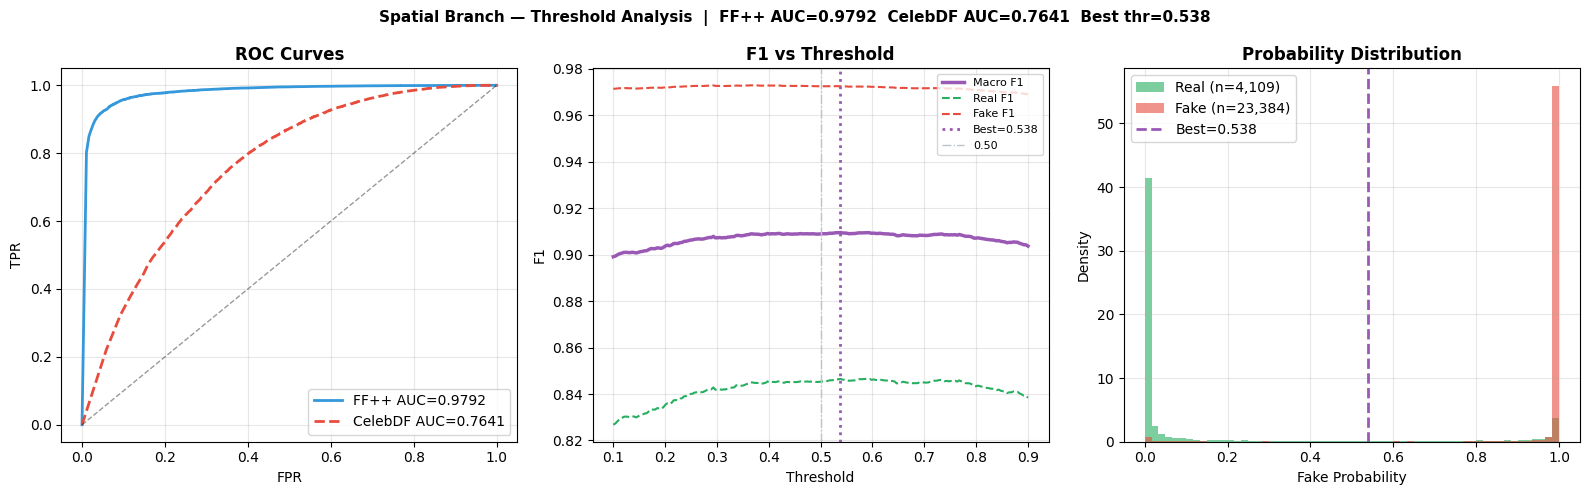

Saved: spatial_threshold_analysis.png


In [21]:
# ══════════════════════════════════════════════
#  ROC-AUC THRESHOLD SWEEP ON FF++ VAL
#  Find optimal threshold for deployment
# ══════════════════════════════════════════════
import matplotlib.pyplot as plt

# Collect val probs
_, _, _, val_probs, val_labels_full = evaluate(
    model, val_loader, desc='Val probs'
)

fpr_v, tpr_v, roc_thr = roc_curve(val_labels_full, val_probs)
val_auc = auc(fpr_v, tpr_v)

# Macro F1 sweep
sweep = np.linspace(0.10, 0.90, 200)
macro_f1s, real_f1s, fake_f1s = [], [], []
for thr in sweep:
    p = [1 if pp >= thr else 0 for pp in val_probs]
    macro_f1s.append(f1_score(val_labels_full, p, average='macro', zero_division=0))
    real_f1s.append( f1_score(val_labels_full, p, pos_label=0, zero_division=0))
    fake_f1s.append( f1_score(val_labels_full, p, pos_label=1, zero_division=0))

best_idx = int(np.argmax(macro_f1s))
best_thr = float(sweep[best_idx])
best_mf1 = float(macro_f1s[best_idx])

j_scores  = tpr_v - fpr_v
youden_thr = float(roc_thr[j_scores.argmax()])

print('=' * 55)
print(f'FF++ Val ROC-AUC:       {val_auc:.4f}')
print(f'CelebDF  ROC-AUC:       {celeb_auc:.4f}')
print(f"Youden's J threshold:   {youden_thr:.3f}")
print(f'Best macro-F1 thresh:   {best_thr:.3f}  (macro_f1={best_mf1:.4f})')
print(f'\n>>> USE THRESHOLD = {best_thr:.3f} IN FUSION AND INFERENCE <<<')

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
ax.plot(fpr_v, tpr_v, color='#3498db', lw=2, label=f'FF++ AUC={val_auc:.4f}')
ax.plot(fpr, tpr, color='#e74c3c', lw=2, linestyle='--',
        label=f'CelebDF AUC={celeb_auc:.4f}')
ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.4)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curves', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(sweep, macro_f1s, color='#9b59b6', lw=2.5, label='Macro F1')
ax.plot(sweep, real_f1s,  color='#27ae60', lw=1.5, linestyle='--', label='Real F1')
ax.plot(sweep, fake_f1s,  color='#e74c3c', lw=1.5, linestyle='--', label='Fake F1')
ax.axvline(best_thr, color='#9b59b6', lw=2, linestyle=':',
           label=f'Best={best_thr:.3f}')
ax.axvline(0.50, color='#bdc3c7', lw=1, linestyle='-.', label='0.50')
ax.set_xlabel('Threshold'); ax.set_ylabel('F1')
ax.set_title('F1 vs Threshold', fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[2]
real_p = [val_probs[i] for i, l in enumerate(val_labels_full) if l == 0]
fake_p = [val_probs[i] for i, l in enumerate(val_labels_full) if l == 1]
ax.hist(real_p, bins=60, alpha=0.6, color='#27ae60',
        label=f'Real (n={len(real_p):,})', density=True)
ax.hist(fake_p, bins=60, alpha=0.6, color='#e74c3c',
        label=f'Fake (n={len(fake_p):,})', density=True)
ax.axvline(best_thr, color='#9b59b6', lw=2, linestyle='--',
           label=f'Best={best_thr:.3f}')
ax.set_xlabel('Fake Probability'); ax.set_ylabel('Density')
ax.set_title('Probability Distribution', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle(
    f'Spatial Branch — Threshold Analysis  |  '
    f'FF++ AUC={val_auc:.4f}  CelebDF AUC={celeb_auc:.4f}  Best thr={best_thr:.3f}',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig(f'{CKPT_DIR}/spatial_threshold_analysis.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: spatial_threshold_analysis.png')

In [22]:
# ══════════════════════════════════════════════
#  FINAL SUMMARY
# ══════════════════════════════════════════════
print('\n' + '=' * 65)
print('SPATIAL BRANCH — FINAL RESULTS')
print('=' * 65)
print(f'Best checkpoint:      epoch {best_ckpt["epoch"]}')
print(f'Optimal threshold:    {best_thr:.3f}')
print(f'\nFF++ Val:')
print(f'  acc={val_ov["acc"]:.4f}  macro_f1={val_ov["macro_f1"]:.4f}  '
      f'real_f1={val_ov["real_f1"]:.4f}  fake_f1={val_ov["fake_f1"]:.4f}')
print(f'  ROC-AUC: {val_auc:.4f}')
print(f'\nFF++ Test:')
print(f'  acc={test_ov["acc"]:.4f}  macro_f1={test_ov["macro_f1"]:.4f}  '
      f'real_f1={test_ov["real_f1"]:.4f}  fake_f1={test_ov["fake_f1"]:.4f}')
print(f'\nCelebDF (cross-dataset generalisation):')
print(f'  acc={celeb_ov["acc"]:.4f}  macro_f1={celeb_ov["macro_f1"]:.4f}  '
      f'real_f1={celeb_ov["real_f1"]:.4f}  fake_f1={celeb_ov["fake_f1"]:.4f}')
print(f'  ROC-AUC: {celeb_auc:.4f}  (published SOTA: 65-76%)')
print(f'\nPer-manipulation (FF++ Test):')
for s, m in sorted(test_per.items(), key=lambda x: x[1]['f1']):
    print(f'  {s:35s}  f1={m["f1"]:.3f}  acc={m["acc"]:.3f}  n={m["n"]}')


SPATIAL BRANCH — FINAL RESULTS
Best checkpoint:      epoch 5
Optimal threshold:    0.538

FF++ Val:
  acc=0.9533  macro_f1=0.9089  real_f1=0.8454  fake_f1=0.9725
  ROC-AUC: 0.9792

FF++ Test:
  acc=0.9555  macro_f1=0.9116  real_f1=0.8493  fake_f1=0.9739

CelebDF (cross-dataset generalisation):
  acc=0.7513  macro_f1=0.6918  real_f1=0.5564  fake_f1=0.8272
  ROC-AUC: 0.7641  (published SOTA: 65-76%)

Per-manipulation (FF++ Test):
  ff_Real                              f1=0.910  acc=0.836  n=3944
  ff_NeuralTextures                    f1=0.972  acc=0.945  n=3744
  ff_FaceSwap                          f1=0.983  acc=0.967  n=4044
  ff_Face2Face                         f1=0.988  acc=0.977  n=3954
  ff_FaceShifter                       f1=0.994  acc=0.987  n=3715
  ff_Deepfakes                         f1=0.994  acc=0.989  n=3875
  ff_DeepFakeDetection                 f1=1.000  acc=1.000  n=3000


In [23]:
# ══════════════════════════════════════════════
#  DOWNLOAD CHECKPOINTS
# ══════════════════════════════════════════════
from IPython.display import FileLink
print(os.listdir(CKPT_DIR))
FileLink('best_model_spatial.pth')

['epoch_04.pth', 'best_model_spatial.pth', 'epoch_02.pth', '.virtual_documents', 'epoch_10.pth', 'epoch_07.pth', 'spatial_threshold_analysis.png', 'epoch_08.pth', 'epoch_03.pth', 'epoch_01.pth', 'epoch_06.pth', 'epoch_05.pth', 'epoch_09.pth']


/kaggle/working/best_model_spatial.pth